# Air Travel Rescue Agent — Development Notebook

Start with the deterministic airline environment before adding LLM agents.

In [1]:
from pathlib import Path
import json

PROJECT_ROOT = Path('..').resolve()
PROJECT_ROOT

PosixPath('/Users/rohitk/mastering_agentic_ai/mastering_agentic_ai_projects/Week_3/air-travel-rescue-agent')

In [2]:
with open(PROJECT_ROOT / 'data' / 'flights.json') as f:
    flights = json.load(f)
flights

[{'flight_number': 'UA100',
  'airline': 'United',
  'origin': 'SFO',
  'destination': 'LAS',
  'departure_time': '2026-08-27T06:20:00',
  'arrival_time': '2026-08-27T09:55:00',
  'stops': 0,
  'available_seats': 1,
  'fare_difference': 275,
  'connection_airports': [],
  'status': 'scheduled',
  'delay_minutes': 0},
 {'flight_number': 'B6101',
  'airline': 'JetBlue',
  'origin': 'SFO',
  'destination': 'LAS',
  'departure_time': '2026-08-27T08:10:00',
  'arrival_time': '2026-08-27T13:01:00',
  'stops': 0,
  'available_seats': 3,
  'fare_difference': 180,
  'connection_airports': [],
  'status': 'scheduled',
  'delay_minutes': 0},
 {'flight_number': 'AS102',
  'airline': 'Alaska',
  'origin': 'SFO',
  'destination': 'LAS',
  'departure_time': '2026-08-27T06:10:00',
  'arrival_time': '2026-08-27T09:06:00',
  'stops': 0,
  'available_seats': 6,
  'fare_difference': 50,
  'connection_airports': [],
  'status': 'scheduled',
  'delay_minutes': 0},
 {'flight_number': 'WN103',
  'airline': 'S

In [20]:
import importlib
import src.tools.flight_tools as flight_tools

importlib.reload(flight_tools)

<module 'src.tools.flight_tools' from '/Users/rohitk/mastering_agentic_ai/mastering_agentic_ai_projects/Week_3/air-travel-rescue-agent/src/tools/flight_tools.py'>

In [21]:
import sys
sys.path.append(str(PROJECT_ROOT))

from src.tools.flight_tools import get_flight_status, search_flights, evaluate_flight_options,rank_flight_options
from src.tools.booking_tools import get_booking_details, rebook_flight
from src.tools.airport_tools import get_nearby_airports

In [4]:
get_flight_status('UA100')

ToolResult(success=True, data={'flight_number': 'UA100', 'airline': 'United', 'origin': 'SFO', 'destination': 'LAS', 'departure_time': '2026-08-27T06:20:00', 'arrival_time': '2026-08-27T09:55:00', 'stops': 0, 'available_seats': 1, 'fare_difference': 275, 'connection_airports': [], 'status': 'scheduled', 'delay_minutes': 0}, error_type=None, error_message=None, retryable=False)

In [ ]:
result=search_flights('SFO', 'LAS')
result

ToolResult(success=True, data=[{'flight_number': 'UA100', 'airline': 'United', 'origin': 'SFO', 'destination': 'LAS', 'departure_time': '2026-08-27T06:20:00', 'arrival_time': '2026-08-27T09:55:00', 'stops': 0, 'available_seats': 1, 'fare_difference': 275, 'connection_airports': [], 'status': 'scheduled', 'delay_minutes': 0}, {'flight_number': 'B6101', 'airline': 'JetBlue', 'origin': 'SFO', 'destination': 'LAS', 'departure_time': '2026-08-27T08:10:00', 'arrival_time': '2026-08-27T13:01:00', 'stops': 0, 'available_seats': 3, 'fare_difference': 180, 'connection_airports': [], 'status': 'scheduled', 'delay_minutes': 0}, {'flight_number': 'AS102', 'airline': 'Alaska', 'origin': 'SFO', 'destination': 'LAS', 'departure_time': '2026-08-27T06:10:00', 'arrival_time': '2026-08-27T09:06:00', 'stops': 0, 'available_seats': 6, 'fare_difference': 50, 'connection_airports': [], 'status': 'scheduled', 'delay_minutes': 0}, {'flight_number': 'WN103', 'airline': 'Southwest', 'origin': 'SFO', 'destination'

In [16]:
#Test evaluation
result = search_flights("SFO", "LAS")

evaluated = evaluate_flight_options(
    result.data,
    arrival_deadline="2026-08-28T11:00:00",
    max_extra_cost=100,
)

evaluated

[{'flight': {'flight_number': 'UA100',
   'airline': 'United',
   'origin': 'SFO',
   'destination': 'LAS',
   'departure_time': '2026-08-27T06:20:00',
   'arrival_time': '2026-08-27T09:55:00',
   'stops': 0,
   'available_seats': 1,
   'fare_difference': 275,
   'connection_airports': [],
   'status': 'scheduled',
   'delay_minutes': 0},
  'meets_deadline': True,
  'within_budget': False,
  'has_seats': True,
  'feasible': False,
  'rejection_reasons': ['Exceeds traveler budget']},
 {'flight': {'flight_number': 'B6101',
   'airline': 'JetBlue',
   'origin': 'SFO',
   'destination': 'LAS',
   'departure_time': '2026-08-27T08:10:00',
   'arrival_time': '2026-08-27T13:01:00',
   'stops': 0,
   'available_seats': 3,
   'fare_difference': 180,
   'connection_airports': [],
   'status': 'scheduled',
   'delay_minutes': 0},
  'meets_deadline': True,
  'within_budget': False,
  'has_seats': True,
  'feasible': False,
  'rejection_reasons': ['Exceeds traveler budget']},
 {'flight': {'flight_nu

In [17]:
result = search_flights("SFO", "LAS")

evaluated = evaluate_flight_options(
    result.data,
    arrival_deadline="2026-08-28T11:00:00",
    max_extra_cost=100,
)

for option in evaluated:
    print(
        option["flight"]["flight_number"],
        option["feasible"],
        option["rejection_reasons"]
    )

UA100 False ['Exceeds traveler budget']
B6101 False ['Exceeds traveler budget']
AS102 True []
WN103 True []
AA171 False ['Arrives after traveler deadline']
WN172 False ['Arrives after traveler deadline']
UA250 False ['Arrives after traveler deadline', 'Exceeds traveler budget']
B6251 False ['Arrives after traveler deadline', 'Exceeds traveler budget']
WN252 False ['Arrives after traveler deadline']
DL253 False ['Arrives after traveler deadline', 'Exceeds traveler budget']
UA901 True []
AA903 True []


In [22]:
ranked = rank_flight_options(evaluated)

for option in ranked:
    flight = option["flight"]
    print(
        flight["flight_number"],
        flight["stops"],
        flight["fare_difference"],
        flight["arrival_time"],
    )

AS102 0 50 2026-08-27T09:06:00
WN103 0 50 2026-08-27T16:06:00
UA901 0 85 2026-08-27T22:42:00
AA903 1 60 2026-08-28T10:15:00


## Next

Once these tools behave correctly, add model initialization and the Intake Agent.

In [54]:
#Initialize the env
from dotenv import load_dotenv
import os

load_dotenv()

NEBIUS_API_KEY = os.getenv("NEBIUS_API_KEY")
MODEL_BASE_URL = os.getenv("MODEL_BASE_URL")
MODEL_NAME = os.getenv("MODEL_NAME")

print("Model:", MODEL_NAME)
print("Base URL:", MODEL_BASE_URL)
print("Nebius key loaded:", bool(NEBIUS_API_KEY))

Model: openai/gpt-oss-120b
Base URL: https://api.tokenfactory.nebius.com/v1/
Nebius key loaded: True


In [229]:
#Initialize LangChain
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=MODEL_NAME,
    api_key=NEBIUS_API_KEY,
    base_url=MODEL_BASE_URL,
    temperature=0,
    max_tokens=2500,
)


In [56]:
#Test
response = llm.invoke(
    "Reply with exactly: Air Travel Rescue Agent ready."
)

print(response.content)

Air Travel Rescue Agent ready.


INTAKE AGENT

In [57]:
#Import Schema
from src.models.schemas import IntakeOutput

print(IntakeOutput.model_json_schema())

{'properties': {'origin': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Origin'}, 'destination': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Destination'}, 'flight_number': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Flight Number'}, 'travel_date': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Travel Date'}, 'booking_id': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Booking Id'}, 'issue_description': {'title': 'Issue Description', 'type': 'string'}, 'arrival_deadline': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Arrival Deadline'}, 'max_extra_cost': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Max Extra Cost'}, 'preferences': {'items': {'type': 'string'}, 'title': 'Preferences', 'type': 'array'}, 'missing_information': {'items': {'type': 'string'}, 'title': 'Missin

In [58]:
#Bind structured output
intake_llm = llm.with_structured_output(IntakeOutput)

#This is important.

#Instead of asking the model: “Please return JSON”

#and then manually parsing whatever it produces, LangChain will ask the model to conform to our Pydantic contract.

In [59]:
#Intake Prompt
from langchain_core.prompts import ChatPromptTemplate

intake_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are the Intake Agent for an Air Travel Rescue system.

Your ONLY job is to extract traveler and disruption information
from the user's message.

Do not recommend flights.
Do not solve the disruption.
Do not make booking decisions.
Do not invent missing information.

Extract:

- origin airport
- destination airport
- flight number
- travel date
- booking ID
- concise issue description
- arrival deadline
- maximum acceptable extra cost
- traveler preferences
- missing information

Rules:

1. Normalize clearly stated airport locations to IATA airport codes
   when unambiguous.
   Example: San Francisco -> SFO, Las Vegas -> LAS.

2. If information is not provided and cannot safely be inferred,
   return null.

3. Put information required to continue the recovery workflow
   in missing_information.

4. Dates/times should use ISO-8601 format where enough information
   is available.

5. Never fabricate flight numbers, booking IDs, dates, or constraints.
"""
    ),
    (
        "human",
        "{traveler_message}"
    )
])

In [60]:
#Combine intake prompt and intake llm
intake_chain = intake_prompt | intake_llm

In [61]:
#Intake test
#Test 1
test_message = """
My United flight UA900 from SFO to Las Vegas was cancelled.
I'm traveling on August 27, 2026.
I need to arrive before 11 AM on August 28.
I can spend up to $100 extra and I'd prefer a nonstop flight.
"""

intake_result = intake_chain.invoke({
    "traveler_message": test_message
})

intake_result

IntakeOutput(origin='SFO', destination='LAS', flight_number='UA900', travel_date='2026-08-27', booking_id=None, issue_description='flight cancelled', arrival_deadline='2026-08-28T11:00', max_extra_cost=100.0, preferences=['nonstop'], missing_information=['booking ID'])

In [62]:
#Test 2 - Missing info
test_message_2 = """
My flight to Boston got cancelled.
I really need to get there tomorrow morning.
"""

intake_result_2 = intake_chain.invoke({
    "traveler_message": test_message_2
})

intake_result_2

IntakeOutput(origin=None, destination='BOS', flight_number=None, travel_date='2026-08-30', booking_id=None, issue_description='Flight cancelled', arrival_deadline=None, max_extra_cost=None, preferences=[], missing_information=['origin airport', 'flight number', 'booking ID', 'arrival deadline time', 'maximum acceptable extra cost', 'traveler preferences'])

In [63]:
#Import intake agent module
import importlib
import src.agents.intake as intake_module

importlib.reload(intake_module)

from src.agents.intake import intake_agent
from langchain_core.messages import HumanMessage

In [64]:
#Mock State
test_state = {
    "messages": [
        HumanMessage(
            content="""
            My United flight UA900 from SFO to Las Vegas was cancelled.
            I'm traveling on August 27, 2026.
            I need to arrive before 11 AM on August 28.
            I can spend up to $100 extra and prefer nonstop.
            """
        )
    ]
}

In [65]:
intake_state_update = intake_agent(
    test_state,
    intake_chain
)

intake_state_update

{'origin': 'SFO',
 'destination': 'LAS',
 'flight_number': 'UA900',
 'travel_date': '2026-08-27',
 'booking_id': None,
 'issue_description': 'flight cancelled',
 'arrival_deadline': '2026-08-28T11:00',
 'max_extra_cost': 100.0,
 'preferences': ['nonstop'],
 'missing_information': ['booking ID']}

TRIAGE AGENT

In [66]:
#Triage Prompt
from langchain_core.prompts import ChatPromptTemplate
from src.models.schemas import TriageOutput

triage_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are the Triage Agent for an Air Travel Rescue system.

Your job is to classify the travel disruption and determine
whether recovery actions are required.

Supported disruption types:
- cancelled
- delayed
- missed_connection
- schedule_change
- unsupported

Severity:
- low
- medium
- high
- critical

Guidelines:

1. CANCELLED
   - Usually requires recovery.
   - Search alternatives should normally be true.

2. DELAYED
   - Recovery may or may not be required.
   - If the delay threatens an arrival deadline or connection,
     recovery should be true.

3. MISSED_CONNECTION
   - Use when a delayed inbound flight makes the onward connection
     impossible or highly unlikely.
   - Recovery should be true.

4. SCHEDULE_CHANGE
   - Use when the airline materially changes the original itinerary.
   - Recovery depends on traveler constraints.

5. UNSUPPORTED
   - Use when the issue is outside the supported flight-recovery scope,
     such as refund disputes, baggage claims, immigration questions,
     medical emergencies, or unrelated requests.

Do not search flights.
Do not recommend a recovery option.
Do not perform booking actions.
Do not invent facts.
"""
    ),
    (
        "human",
        """
Traveler intake:

Origin: {origin}
Destination: {destination}
Flight number: {flight_number}
Travel date: {travel_date}
Issue: {issue_description}
Arrival deadline: {arrival_deadline}
Maximum extra cost: {max_extra_cost}
Preferences: {preferences}
"""
    )
])

In [67]:
#Bind the Triage Structured Output
triage_llm = llm.with_structured_output(TriageOutput)

triage_chain = triage_prompt | triage_llm

In [68]:
#Test triage chain with intake result
triage_result = triage_chain.invoke({
    "origin": intake_state_update["origin"],
    "destination": intake_state_update["destination"],
    "flight_number": intake_state_update["flight_number"],
    "travel_date": intake_state_update["travel_date"],
    "issue_description": intake_state_update["issue_description"],
    "arrival_deadline": intake_state_update["arrival_deadline"],
    "max_extra_cost": intake_state_update["max_extra_cost"],
    "preferences": intake_state_update["preferences"],
})

triage_result

TriageOutput(disruption_type=<DisruptionType.CANCELLED: 'cancelled'>, severity=<Severity.HIGH: 'high'>, recovery_required=True, search_alternatives=True, urgency_reason='The flight on 2026-08-27 has been cancelled, and the traveler must arrive by 2026-08-28T11:00. Prompt re‑booking is needed to meet the deadline.', unsupported_reason=None)

In [69]:
#Reload triage module
import importlib
import src.agents.triage as triage_module

importlib.reload(triage_module)

from src.agents.triage import triage_agent

In [70]:
#Create Triage State with Intake Output
triage_test_state = {
    **test_state,
    **intake_state_update,
}

In [71]:
#Run the state
triage_state_update = triage_agent(
    triage_test_state,
    triage_chain
)

triage_state_update

{'disruption_type': <DisruptionType.CANCELLED: 'cancelled'>,
 'severity': <Severity.HIGH: 'high'>,
 'recovery_required': True,
 'search_alternatives': True}

In [72]:
flight_status_result = get_flight_status(
    triage_test_state["flight_number"]
)

flight_status_result

ToolResult(success=True, data={'flight_number': 'UA900', 'airline': 'United', 'origin': 'SFO', 'destination': 'LAS', 'departure_time': '2026-08-27T18:00:00', 'arrival_time': '2026-08-27T19:35:00', 'stops': 0, 'available_seats': 0, 'fare_difference': 0, 'connection_airports': [], 'status': 'cancelled', 'delay_minutes': 0}, error_type=None, error_message=None, retryable=False)

In [73]:
flight_status_result.data

{'flight_number': 'UA900',
 'airline': 'United',
 'origin': 'SFO',
 'destination': 'LAS',
 'departure_time': '2026-08-27T18:00:00',
 'arrival_time': '2026-08-27T19:35:00',
 'stops': 0,
 'available_seats': 0,
 'fare_difference': 0,
 'connection_airports': [],
 'status': 'cancelled',
 'delay_minutes': 0}

In [74]:
#Update state with original flight
current_state = {
    **triage_test_state,
    **triage_state_update,
    "original_flight": flight_status_result.data
}

current_state

{'messages': [HumanMessage(content="\n            My United flight UA900 from SFO to Las Vegas was cancelled.\n            I'm traveling on August 27, 2026.\n            I need to arrive before 11 AM on August 28.\n            I can spend up to $100 extra and prefer nonstop.\n            ", additional_kwargs={}, response_metadata={})],
 'origin': 'SFO',
 'destination': 'LAS',
 'flight_number': 'UA900',
 'travel_date': '2026-08-27',
 'booking_id': None,
 'issue_description': 'flight cancelled',
 'arrival_deadline': '2026-08-28T11:00',
 'max_extra_cost': 100.0,
 'preferences': ['nonstop'],
 'missing_information': ['booking ID'],
 'disruption_type': <DisruptionType.CANCELLED: 'cancelled'>,
 'severity': <Severity.HIGH: 'high'>,
 'recovery_required': True,
 'search_alternatives': True,
 'original_flight': {'flight_number': 'UA900',
  'airline': 'United',
  'origin': 'SFO',
  'destination': 'LAS',
  'departure_time': '2026-08-27T18:00:00',
  'arrival_time': '2026-08-27T19:35:00',
  'stops': 

In [75]:
#Only search if Triage says recovery is needed
if current_state["search_alternatives"]:
    search_result = search_flights(
        origin=current_state["origin"],
        destination=current_state["destination"],
    )
else:
    search_result = None

In [76]:
search_result

ToolResult(success=True, data=[{'flight_number': 'UA100', 'airline': 'United', 'origin': 'SFO', 'destination': 'LAS', 'departure_time': '2026-08-27T06:20:00', 'arrival_time': '2026-08-27T09:55:00', 'stops': 0, 'available_seats': 1, 'fare_difference': 275, 'connection_airports': [], 'status': 'scheduled', 'delay_minutes': 0}, {'flight_number': 'B6101', 'airline': 'JetBlue', 'origin': 'SFO', 'destination': 'LAS', 'departure_time': '2026-08-27T08:10:00', 'arrival_time': '2026-08-27T13:01:00', 'stops': 0, 'available_seats': 3, 'fare_difference': 180, 'connection_airports': [], 'status': 'scheduled', 'delay_minutes': 0}, {'flight_number': 'AS102', 'airline': 'Alaska', 'origin': 'SFO', 'destination': 'LAS', 'departure_time': '2026-08-27T06:10:00', 'arrival_time': '2026-08-27T09:06:00', 'stops': 0, 'available_seats': 6, 'fare_difference': 50, 'connection_airports': [], 'status': 'scheduled', 'delay_minutes': 0}, {'flight_number': 'WN103', 'airline': 'Southwest', 'origin': 'SFO', 'destination'

In [77]:
#Apply constraints extracted by Intake
evaluated_options = evaluate_flight_options(
    search_result.data,
    arrival_deadline=current_state.get("arrival_deadline"),
    max_extra_cost=current_state.get("max_extra_cost"),
)

evaluated_options

[{'flight': {'flight_number': 'UA100',
   'airline': 'United',
   'origin': 'SFO',
   'destination': 'LAS',
   'departure_time': '2026-08-27T06:20:00',
   'arrival_time': '2026-08-27T09:55:00',
   'stops': 0,
   'available_seats': 1,
   'fare_difference': 275,
   'connection_airports': [],
   'status': 'scheduled',
   'delay_minutes': 0},
  'meets_deadline': True,
  'within_budget': False,
  'has_seats': True,
  'feasible': False,
  'rejection_reasons': ['Exceeds traveler budget']},
 {'flight': {'flight_number': 'B6101',
   'airline': 'JetBlue',
   'origin': 'SFO',
   'destination': 'LAS',
   'departure_time': '2026-08-27T08:10:00',
   'arrival_time': '2026-08-27T13:01:00',
   'stops': 0,
   'available_seats': 3,
   'fare_difference': 180,
   'connection_airports': [],
   'status': 'scheduled',
   'delay_minutes': 0},
  'meets_deadline': True,
  'within_budget': False,
  'has_seats': True,
  'feasible': False,
  'rejection_reasons': ['Exceeds traveler budget']},
 {'flight': {'flight_nu

In [78]:
#Inspect the alternatives suggested above
for option in evaluated_options:
    flight = option["flight"]

    print(
        flight["flight_number"],
        "| fare:", flight["fare_difference"],
        "| arrival:", flight["arrival_time"],
        "| feasible:", option["feasible"],
        "| reasons:", option["rejection_reasons"]
    )

UA100 | fare: 275 | arrival: 2026-08-27T09:55:00 | feasible: False | reasons: ['Exceeds traveler budget']
B6101 | fare: 180 | arrival: 2026-08-27T13:01:00 | feasible: False | reasons: ['Exceeds traveler budget']
AS102 | fare: 50 | arrival: 2026-08-27T09:06:00 | feasible: True | reasons: []
WN103 | fare: 50 | arrival: 2026-08-27T16:06:00 | feasible: True | reasons: []
AA171 | fare: 65 | arrival: 2026-08-28T20:53:00 | feasible: False | reasons: ['Arrives after traveler deadline']
WN172 | fare: 50 | arrival: 2026-08-28T18:45:00 | feasible: False | reasons: ['Arrives after traveler deadline']
UA250 | fare: 110 | arrival: 2026-08-29T18:58:00 | feasible: False | reasons: ['Arrives after traveler deadline', 'Exceeds traveler budget']
B6251 | fare: 275 | arrival: 2026-08-29T13:43:00 | feasible: False | reasons: ['Arrives after traveler deadline', 'Exceeds traveler budget']
WN252 | fare: 85 | arrival: 2026-08-29T09:28:00 | feasible: False | reasons: ['Arrives after traveler deadline']
DL253 | f

In [79]:
#Rank viable options
ranked_options = rank_flight_options(
    evaluated_options
)

In [80]:
for i, option in enumerate(ranked_options, start=1):
    flight = option["flight"]

    print(
        i,
        flight["flight_number"],
        "| stops:", flight["stops"],
        "| extra cost:", flight["fare_difference"],
        "| arrival:", flight["arrival_time"]
    )

1 AS102 | stops: 0 | extra cost: 50 | arrival: 2026-08-27T09:06:00
2 WN103 | stops: 0 | extra cost: 50 | arrival: 2026-08-27T16:06:00
3 UA901 | stops: 0 | extra cost: 85 | arrival: 2026-08-27T22:42:00
4 AA903 | stops: 1 | extra cost: 60 | arrival: 2026-08-28T10:15:00


In [81]:
#Store recovery results in state
current_state.update({
    "alternative_flights": search_result.data,
    "evaluated_options": evaluated_options,
    "ranked_options": ranked_options,
})

In [82]:
current_state.keys()

dict_keys(['messages', 'origin', 'destination', 'flight_number', 'travel_date', 'booking_id', 'issue_description', 'arrival_deadline', 'max_extra_cost', 'preferences', 'missing_information', 'disruption_type', 'severity', 'recovery_required', 'search_alternatives', 'original_flight', 'alternative_flights', 'evaluated_options', 'ranked_options'])

CREATE NODE

In [84]:
#Reload and test the node
import importlib
import src.graph.nodes as nodes_module

importlib.reload(nodes_module)

from src.graph.nodes import flight_recovery_node


In [85]:
recovery_state_update = flight_recovery_node(
    current_state
)

recovery_state_update

{'original_flight': {'flight_number': 'UA900',
  'airline': 'United',
  'origin': 'SFO',
  'destination': 'LAS',
  'departure_time': '2026-08-27T18:00:00',
  'arrival_time': '2026-08-27T19:35:00',
  'stops': 0,
  'available_seats': 0,
  'fare_difference': 0,
  'connection_airports': [],
  'status': 'cancelled',
  'delay_minutes': 0},
 'alternative_flights': [{'flight_number': 'UA100',
   'airline': 'United',
   'origin': 'SFO',
   'destination': 'LAS',
   'departure_time': '2026-08-27T06:20:00',
   'arrival_time': '2026-08-27T09:55:00',
   'stops': 0,
   'available_seats': 1,
   'fare_difference': 275,
   'connection_airports': [],
   'status': 'scheduled',
   'delay_minutes': 0},
  {'flight_number': 'B6101',
   'airline': 'JetBlue',
   'origin': 'SFO',
   'destination': 'LAS',
   'departure_time': '2026-08-27T08:10:00',
   'arrival_time': '2026-08-27T13:01:00',
   'stops': 0,
   'available_seats': 3,
   'fare_difference': 180,
   'connection_airports': [],
   'status': 'scheduled',
  

In [86]:
for option in recovery_state_update["ranked_options"]:
    flight = option["flight"]
    print(
        flight["flight_number"],
        flight["fare_difference"],
        flight["stops"]
    )

AS102 50 0
WN103 50 0
UA901 85 0
AA903 60 1


RECOVERY PLANNER AGENT

In [87]:
#Planner Prompt
from langchain_core.prompts import ChatPromptTemplate
from src.models.schemas import PlannerOutput

planner_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are the Recovery Planner Agent for an Air Travel Rescue system.

Your job is to choose the best recovery option from the viable flight
alternatives already evaluated by deterministic code.

Do NOT invent flights.
Do NOT choose flights that are not in the provided ranked options.
Do NOT recalculate feasibility.
Do NOT perform booking actions.

Consider:

- arrival deadline
- traveler preferences
- number of stops
- additional cost
- departure time
- arrival time
- convenience of staying at the same origin airport

Guidelines:

1. Prefer options that satisfy all traveler constraints.
2. Prefer nonstop over connecting flights when other factors are reasonably similar.
3. Prefer lower additional cost when it does not significantly worsen the itinerary.
4. Prefer earlier arrival when the traveler has urgency or an arrival deadline.
5. Do not select a more expensive option without a clear traveler benefit.
6. If no options are available, return plan_available=false.
7. Any rebooking action requires explicit traveler approval.
8. Provide concise decision factors, not hidden chain-of-thought.
"""
    ),
    (
        "human",
        """
Traveler context:

Origin: {origin}
Destination: {destination}
Arrival deadline: {arrival_deadline}
Maximum extra cost: {max_extra_cost}
Preferences: {preferences}

Viable ranked flight options:

{ranked_options}
"""
    )
])

In [88]:
#Bind structured output for Planner
planner_llm = llm.with_structured_output(PlannerOutput)

planner_chain = planner_prompt | planner_llm

In [89]:
#Prepare planner input
planner_options = []

for option in recovery_state_update["ranked_options"]:
    flight = option["flight"]

    planner_options.append({
        "flight_number": flight["flight_number"],
        "airline": flight["airline"],
        "origin": flight["origin"],
        "destination": flight["destination"],
        "departure_time": flight["departure_time"],
        "arrival_time": flight["arrival_time"],
        "stops": flight["stops"],
        "fare_difference": flight["fare_difference"],
        "available_seats": flight["available_seats"],
    })

planner_options

[{'flight_number': 'AS102',
  'airline': 'Alaska',
  'origin': 'SFO',
  'destination': 'LAS',
  'departure_time': '2026-08-27T06:10:00',
  'arrival_time': '2026-08-27T09:06:00',
  'stops': 0,
  'fare_difference': 50,
  'available_seats': 6},
 {'flight_number': 'WN103',
  'airline': 'Southwest',
  'origin': 'SFO',
  'destination': 'LAS',
  'departure_time': '2026-08-27T13:30:00',
  'arrival_time': '2026-08-27T16:06:00',
  'stops': 0,
  'fare_difference': 50,
  'available_seats': 2},
 {'flight_number': 'UA901',
  'airline': 'United',
  'origin': 'SFO',
  'destination': 'LAS',
  'departure_time': '2026-08-27T21:10:00',
  'arrival_time': '2026-08-27T22:42:00',
  'stops': 0,
  'fare_difference': 85,
  'available_seats': 7},
 {'flight_number': 'AA903',
  'airline': 'American',
  'origin': 'SFO',
  'destination': 'LAS',
  'departure_time': '2026-08-28T07:00:00',
  'arrival_time': '2026-08-28T10:15:00',
  'stops': 1,
  'fare_difference': 60,
  'available_seats': 3}]

In [90]:
#Invoke Planner Agent
planner_result = planner_chain.invoke({
    "origin": current_state["origin"],
    "destination": current_state["destination"],
    "arrival_deadline": current_state.get("arrival_deadline"),
    "max_extra_cost": current_state.get("max_extra_cost"),
    "preferences": current_state.get("preferences", []),
    "ranked_options": planner_options,
})

planner_result

PlannerOutput(plan_available=True, recommended_plan=RecoveryPlan(recommended_flight_number='AS102', decision_factors=[PlanDecisionFactor(factor='nonstop', assessment='meets preference'), PlanDecisionFactor(factor='arrival_before_deadline', assessment='arrives 2026-08-27T09:06, well before 11:00 deadline'), PlanDecisionFactor(factor='extra_cost', assessment='fare difference $50, within $100 limit'), PlanDecisionFactor(factor='arrival_time', assessment='earliest arrival among nonstop options'), PlanDecisionFactor(factor='cost_vs_arrival', assessment='lowest cost among earliest-arriving nonstop flights')], estimated_extra_cost=50.0, requires_booking_change=True, requires_user_approval=True, confidence=0.97), alternatives_considered=['WN103 (nonstop, later arrival, same cost)', 'UA901 (nonstop, later arrival, higher cost)', 'AA903 (1 stop, does not meet nonstop preference)'], no_plan_reason=None)

In [91]:
#Validate the Planner
valid_flight_numbers = {
    option["flight"]["flight_number"]
    for option in recovery_state_update["ranked_options"]
}

recommended_flight = (
    planner_result.recommended_plan.recommended_flight_number
    if planner_result.recommended_plan
    else None
)

assert recommended_flight in valid_flight_numbers, (
    f"Planner selected invalid flight: {recommended_flight}"
)

print("Planner selected valid flight:", recommended_flight)

Planner selected valid flight: AS102


In [92]:
#Import Planner Module
import importlib
import src.agents.planner as planner_module

importlib.reload(planner_module)

from src.agents.planner import planner_agent

In [ ]:
#Build planner state
planner_test_state = {
    **current_state,
    **recovery_state_update,
}

In [94]:
planner_state_update = planner_agent(
    planner_test_state,
    planner_chain
)

planner_state_update

{'planner_output': PlannerOutput(plan_available=True, recommended_plan=RecoveryPlan(recommended_flight_number='AS102', decision_factors=[PlanDecisionFactor(factor='meets_nonstop_preference', assessment='yes'), PlanDecisionFactor(factor='arrival_before_deadline', assessment='yes (09:06 on 2026-08-27)'), PlanDecisionFactor(factor='fare_difference_within_budget', assessment='yes (50 ≤ 100)'), PlanDecisionFactor(factor='lowest_cost_among_nonstop', assessment='yes (tied with WN103, but earlier departure)'), PlanDecisionFactor(factor='earlier_arrival', assessment='yes (09:06 vs 16:06)'), PlanDecisionFactor(factor='seat_availability', assessment='yes (6 seats)')], estimated_extra_cost=50.0, requires_booking_change=True, requires_user_approval=True, confidence=0.97), alternatives_considered=['WN103 (same cost but later departure/arrival)', 'UA901 (higher cost, later arrival)', 'AA903 (1 stop, not preferred)'], no_plan_reason=None),
 'recommended_plan': RecoveryPlan(recommended_flight_number='A

HITL Approval

In [95]:
#Create Pending Action
#We want the planner to recommend a flight, but the system must not rebook anything until the traveler explicitly approves
from src.models.schemas import (
    PendingAction,
    ActionType,
    ApprovalStatus,
)

recommended_plan = planner_state_update["recommended_plan"]

pending_action = PendingAction(
    action_type=ActionType.REBOOK_FLIGHT,
    description=(
        f"Rebook traveler onto "
        f"{recommended_plan.recommended_flight_number}"
    ),
    flight_number=recommended_plan.recommended_flight_number,
    additional_cost=recommended_plan.estimated_extra_cost,
    requires_approval=True,
)

pending_action

PendingAction(action_type=<ActionType.REBOOK_FLIGHT: 'rebook_flight'>, description='Rebook traveler onto AS102', flight_number='AS102', additional_cost=50.0, requires_approval=True)

In [96]:
#Add Pending Action to State
approval_state = {
    **planner_test_state,
    **planner_state_update,
    "pending_action": pending_action,
    "approval_status": ApprovalStatus.PENDING,
}

approval_state["pending_action"]

PendingAction(action_type=<ActionType.REBOOK_FLIGHT: 'rebook_flight'>, description='Rebook traveler onto AS102', flight_number='AS102', additional_cost=50.0, requires_approval=True)

In [97]:
#Generate traveler-facing approval message
def build_approval_message(state):
    action = state["pending_action"]

    return (
        f"I found a recovery option on flight "
        f"{action.flight_number} with an additional cost of "
        f"${action.additional_cost:.2f}. "
        f"Would you like me to rebook you onto this flight?"
    )

In [98]:
approval_message = build_approval_message(approval_state)

print(approval_message)

I found a recovery option on flight AS102 with an additional cost of $50.00. Would you like me to rebook you onto this flight?


In [99]:
#simulate traveler approval
#For now, we manually simulate the HITL step:
traveler_response = "yes"

In [100]:
#Add deterministic parser
def parse_approval(response: str) -> ApprovalStatus:
    normalized = response.strip().lower()

    if normalized in {"yes", "y", "approve", "approved", "go ahead", "book it"}:
        return ApprovalStatus.APPROVED

    if normalized in {"no", "n", "reject", "cancel", "don't book", "do not book"}:
        return ApprovalStatus.REJECTED

    return ApprovalStatus.PENDING

In [101]:
approval_status = parse_approval(traveler_response)

approval_status

<ApprovalStatus.APPROVED: 'approved'>

In [102]:
#Update state
approval_state["approval_status"] = approval_status

In [103]:
approval_state["approval_status"]

<ApprovalStatus.APPROVED: 'approved'>

In [106]:
#Manual booking id for demo
approval_state["booking_id"] = "BR1001"

In [ ]:
#Execute Rebooking only if approved
from src.tools.booking_tools import rebook_flight

if approval_state["approval_status"] == ApprovalStatus.APPROVED:
#we should not allow the graph to reach rebook_flight() when booking_id is missing
    booking_result = rebook_flight(
        booking_id=approval_state["booking_id"],
        new_flight_number=approval_state["pending_action"].flight_number,
        user_approved=True,
    )

else:
    booking_result = None

In [108]:
#Verify booking result
from src.tools.booking_tools import get_booking_details

updated_booking = get_booking_details(
    approval_state["booking_id"]
)

updated_booking

ToolResult(success=True, data={'booking_id': 'BR1001', 'traveler_id': 'TR001', 'traveler_name': 'Alex Morgan', 'flight_number': 'AS102', 'origin': 'SFO', 'destination': 'LAS', 'travel_date': '2026-08-27', 'status': 'rebooked', 'fare_class': 'Economy', 'ticket_value': 245}, error_type=None, error_message=None, retryable=False)

In [ ]:
#Verify the test write actually happened
from src.tools.booking_tools import get_booking_details

updated_booking = get_booking_details(
    approval_state["booking_id"]
)

updated_booking

#That proves this is not merely generating a recommendation. 
#The workflow actually modifies state through a tool.

ToolResult(success=True, data={'booking_id': 'BR1001', 'traveler_id': 'TR001', 'traveler_name': 'Alex Morgan', 'flight_number': 'AS102', 'origin': 'SFO', 'destination': 'LAS', 'travel_date': '2026-08-27', 'status': 'rebooked', 'fare_class': 'Economy', 'ticket_value': 245}, error_type=None, error_message=None, retryable=False)

In [110]:
#Test traveler rejection
traveler_response = "no"

approval_status = parse_approval(
    traveler_response
)

approval_status

<ApprovalStatus.REJECTED: 'rejected'>

In [111]:
#Add booking validation node
def validate_booking_node(state):
    booking_id = state.get("booking_id")

    if not booking_id:
        return {
            "last_error": "Booking ID is required before rebooking.",
            "escalation_required": False,
        }

    return {
        "last_error": None
    }

In [112]:
#Resolution check node
from src.models.schemas import ResolutionStatus


def resolution_check_node(state):
    if state.get("booking_updated"):
        return {
            "resolution_status": ResolutionStatus.RESOLVED,
            "resolution_summary": (
                f"Traveler successfully rebooked onto "
                f"{state['pending_action'].flight_number}."
            )
        }

    return {
        "resolution_status": ResolutionStatus.IN_PROGRESS,
        "resolution_summary": None,
    }

In [113]:
#Escalation node
from src.models.schemas import (
    EscalationOutput,
    EscalationReason,
    Severity,
    ResolutionStatus,
)


def escalation_node(state):
    reason = EscalationReason.OTHER
    summary = "Automated recovery could not be completed."

    if state.get("last_error"):
        reason = EscalationReason.TOOL_FAILURE
        summary = state["last_error"]

    elif not state.get("ranked_options"):
        reason = EscalationReason.NO_VIABLE_FLIGHT
        summary = "No viable recovery flight was found."

    escalation = EscalationOutput(
        escalation_required=True,
        reason=reason,
        priority=state.get("severity", Severity.HIGH),
        summary=summary,
        actions_attempted=[
            record.action
            for record in state.get("action_history", [])
        ],
        recommended_human_action=(
            "A human travel support agent should review the itinerary "
            "and determine the next available recovery option."
        ),
    )

    return {
        "escalation_required": True,
        "escalation_output": escalation,
        "resolution_status": ResolutionStatus.ESCALATED,
    }

TEST SUCCESSFUL PATH

In [ ]:
#Reload node module


In [115]:
validation_result = validate_booking_node(
    approval_state
)

validation_result

{'last_error': None}

In [116]:
post_booking_state = {
    **approval_state,
    "booking_updated": booking_result.success,
}

In [117]:
resolution_result = resolution_check_node(
    post_booking_state
)

resolution_result

{'resolution_status': <ResolutionStatus.RESOLVED: 'resolved'>,
 'resolution_summary': 'Traveler successfully rebooked onto AS102.'}

TEST ESCALATION

In [118]:
#Create a failure state
failure_state = {
    **current_state,
    "ranked_options": [],
    "last_error": None,
}

In [119]:
escalation_result = escalation_node(
    failure_state
)

escalation_result

{'escalation_required': True,
 'escalation_output': EscalationOutput(escalation_required=True, reason=<EscalationReason.NO_VIABLE_FLIGHT: 'no_viable_flight'>, priority=<Severity.HIGH: 'high'>, summary='No viable recovery flight was found.', actions_attempted=[], recommended_human_action='A human travel support agent should review the itinerary and determine the next available recovery option.'),
 'resolution_status': <ResolutionStatus.ESCALATED: 'escalated'>}

SETUP LANGGRAPH

In [120]:
from langgraph.graph import StateGraph, START, END

from src.graph.state import TravelState

from src.agents.intake import intake_agent
from src.agents.triage import triage_agent
from src.agents.planner import planner_agent

from src.graph.nodes import (
    flight_recovery_node,
    create_pending_action_node,
    execute_rebooking_node,
    resolution_check_node,
    escalation_node,
)

from src.models.schemas import ApprovalStatus

In [121]:
#Create wrapper nodes
def intake_node(state):
    return intake_agent(
        state,
        intake_chain
    )


def triage_node(state):
    return triage_agent(
        state,
        triage_chain
    )


def planner_node(state):
    return planner_agent(
        state,
        planner_chain
    )

In [128]:
#Create Routing Functions
def route_after_intake(state):

    if state.get("missing_information"):
        return "missing_information"

    return "triage"


def route_after_triage(state):

    if not state.get("recovery_required"):
        return "escalate"

    if not state.get("search_alternatives"):
        return "escalate"

    return "flight_recovery"


def route_after_recovery(state):

    if state.get("last_error"):
        return "escalate"

    if not state.get("ranked_options"):
        return "escalate"

    return "planner"


def route_after_planner(state):

    if not state.get("recommended_plan"):
        return "escalate"

    return "create_pending_action"


def route_after_approval(state):

    status = state.get("approval_status")

    if status == ApprovalStatus.APPROVED:
        return "execute_rebooking"

    if status == ApprovalStatus.REJECTED:
        return "escalate"

    return "await_approval"


def route_after_execution(state):

    if state.get("booking_updated"):
        return "resolution_check"

    return "escalate"

#For now, rejection escalates rather than replanning. We can make rejection loop back to the Planner later.

In [ ]:
#Temporary missing-information node
def missing_information_node(state):

    missing = state.get(
        "missing_information",
        []
    )

    return {
        "resolution_summary": (
            "Additional traveler information is required: "
            + ", ".join(missing)
        )
    }

In [123]:
#Temporary approval node
def await_approval_node(state):

    return {
        "approval_status": state.get(
            "approval_status",
            ApprovalStatus.PENDING
        )
    }

In [124]:
#Build the graph
builder = StateGraph(TravelState)

In [125]:
#Add Nodes
builder.add_node(
    "intake",
    intake_node
)

builder.add_node(
    "missing_information",
    missing_information_node
)

builder.add_node(
    "triage",
    triage_node
)

builder.add_node(
    "flight_recovery",
    flight_recovery_node
)

builder.add_node(
    "planner",
    planner_node
)

builder.add_node(
    "create_pending_action",
    create_pending_action_node
)

builder.add_node(
    "await_approval",
    await_approval_node
)

builder.add_node(
    "execute_rebooking",
    execute_rebooking_node
)

builder.add_node(
    "resolution_check",
    resolution_check_node
)

builder.add_node(
    "escalate",
    escalation_node
)

In [126]:
#Connect the beginning
builder.add_edge(
    START,
    "intake"
)

In [129]:
#Conditional routing after intake
builder.add_conditional_edges(
    "intake",
    route_after_intake,
    {
        "missing_information": "missing_information",
        "triage": "triage",
    }
)

In [ ]:
#For Testing purposes
builder.add_edge(
    "missing_information",
    END
)
#Later this node will actually pause and ask the traveler.

In [131]:
#Connec Triage and Recovery
builder.add_conditional_edges(
    "triage",
    route_after_triage,
    {
        "flight_recovery": "flight_recovery",
        "escalate": "escalate",
    }
)

In [132]:
#Add conditional edges
builder.add_conditional_edges(
    "flight_recovery",
    route_after_recovery,
    {
        "planner": "planner",
        "escalate": "escalate",
    }
)

In [133]:
#Planner Routing
builder.add_conditional_edges(
    "planner",
    route_after_planner,
    {
        "create_pending_action": "create_pending_action",
        "escalate": "escalate",
    }
)

In [134]:
builder.add_edge(
    "create_pending_action",
    "await_approval"
)

In [135]:
#Approval Routing
builder.add_conditional_edges(
    "await_approval",
    route_after_approval,
    {
        "execute_rebooking": "execute_rebooking",
        "await_approval": END,
        "escalate": "escalate",
    }
)

In [136]:
#Execution and Result
builder.add_conditional_edges(
    "execute_rebooking",
    route_after_execution,
    {
        "resolution_check": "resolution_check",
        "escalate": "escalate",
    }
)

In [137]:
builder.add_edge(
    "resolution_check",
    END
)

builder.add_edge(
    "escalate",
    END
)

In [138]:
#COMPILE GRAPH
graph = builder.compile()

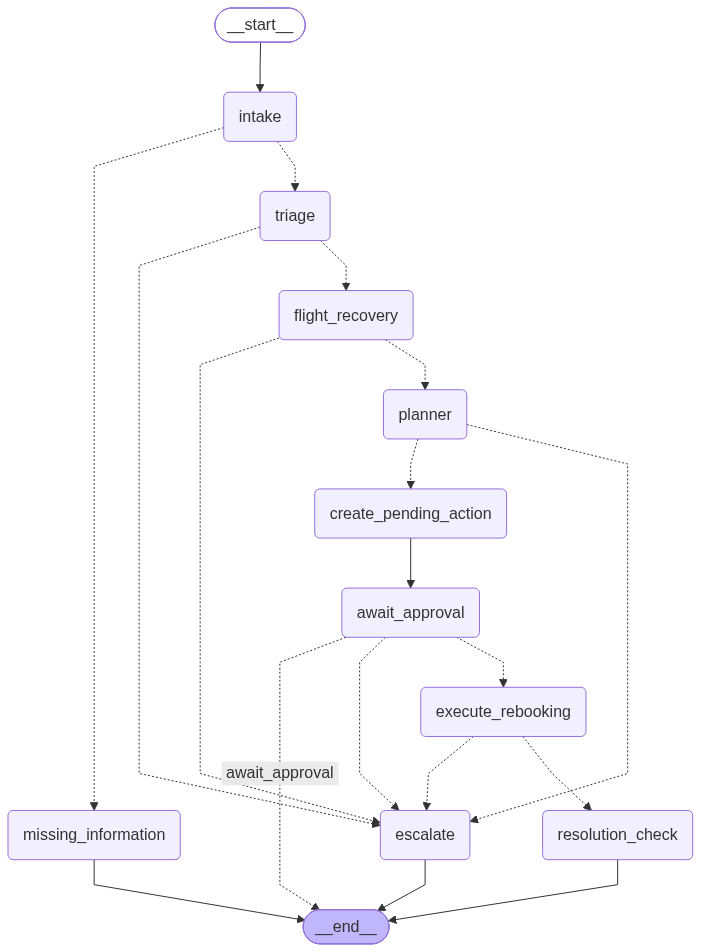

In [139]:
graph

In [140]:
#Run the graph
from langchain_core.messages import HumanMessage

initial_state = {
    "messages": [
        HumanMessage(
            content="""
            My United flight UA900 from SFO to Las Vegas was cancelled.
            My booking ID is BR1001.
            I'm traveling on August 27, 2026.
            I need to arrive before 11 AM on August 28.
            I can spend up to $100 extra and prefer nonstop.
            """
        )
    ],

    "approval_status": ApprovalStatus.PENDING,
    "retry_count": 0,
}

In [141]:
result = graph.invoke(
    initial_state
)

In [142]:
result

{'messages': [HumanMessage(content="\n            My United flight UA900 from SFO to Las Vegas was cancelled.\n            My booking ID is BR1001.\n            I'm traveling on August 27, 2026.\n            I need to arrive before 11 AM on August 28.\n            I can spend up to $100 extra and prefer nonstop.\n            ", additional_kwargs={}, response_metadata={})],
 'booking_id': 'BR1001',
 'origin': 'SFO',
 'destination': 'LAS',
 'flight_number': 'UA900',
 'travel_date': '2026-08-27',
 'issue_description': 'flight cancelled',
 'arrival_deadline': '2026-08-28T11:00:00',
 'max_extra_cost': 100.0,
 'preferences': ['nonstop'],
 'missing_information': [],
 'disruption_type': <DisruptionType.CANCELLED: 'cancelled'>,
 'severity': <Severity.HIGH: 'high'>,
 'recovery_required': True,
 'original_flight': {'flight_number': 'UA900',
  'airline': 'United',
  'origin': 'SFO',
  'destination': 'LAS',
  'departure_time': '2026-08-27T18:00:00',
  'arrival_time': '2026-08-27T19:35:00',
  'stops

In [143]:
print(
    "Disruption:",
    result.get("disruption_type")
)

print(
    "Recommended:",
    result.get("recommended_plan")
)

print(
    "Pending action:",
    result.get("pending_action")
)

print(
    "Approval:",
    result.get("approval_status")
)

Disruption: DisruptionType.CANCELLED
Recommended: None
Pending action: None
Approval: ApprovalStatus.PENDING


          LangGraph
              │
     decides next node
              │
     based on shared state
              │
          executes tools
              │
      branches on outcomes

In [144]:
#Import HITL checkpoint pieces
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

In [ ]:
#Replace Temporary created approval node
def await_approval_node(state):

    action = state["pending_action"]

    response = interrupt({
        "type": "approval_required",
        "message": (
            f"Rebook onto {action.flight_number} "
            f"for an additional ${action.additional_cost:.2f}?"
        ),
        "flight_number": action.flight_number,
        "additional_cost": action.additional_cost,
    })

    normalized = str(response).strip().lower()

    if normalized in {
        "yes", "y", "approve", "approved",
        "go ahead", "book it"
    }:
        status = ApprovalStatus.APPROVED

    elif normalized in {
        "no", "n", "reject", "cancel",
        "don't book", "do not book"
    }:
        status = ApprovalStatus.REJECTED

    else:
        status = ApprovalStatus.PENDING

    return {
        "approval_status": status
    }

#Important line is interrupt(...)
#Execution pauses there until we resume the graph.

In [309]:
import importlib
import src.graph.nodes as nodes_module

importlib.reload(nodes_module)

from src.graph.nodes import (
    flight_recovery_node,
    create_pending_action_node,
    execute_rebooking_node,
    resolution_check_node,
    escalation_node,
    retry_handler_node
)

In [271]:
debug_state = {
    "flight_number": "UA900",
    "origin": "SFO",
    "destination": "LAS",
    "arrival_deadline": "2026-08-28T11:00",
    "max_extra_cost": 100,
    "simulate_search_failure": True,
    "retry_count": 0,
}

first_attempt = flight_recovery_node(debug_state)

print("FIRST ATTEMPT")
print("Success:", first_attempt["last_tool_result"].success)
print("Error:", first_attempt["last_error"])

FIRST ATTEMPT
Success: False
Error: Flight inventory service is temporarily unavailable.


In [253]:
from langgraph.graph import StateGraph, START, END
from src.graph.state import TravelState

# Fresh builder - Recompiling
builder = StateGraph(TravelState)

builder.add_node("intake", intake_node)
builder.add_node("missing_information", missing_information_node)
builder.add_node("triage", triage_node)
builder.add_node("flight_recovery", flight_recovery_node)
builder.add_node("planner", planner_node)
builder.add_node("create_pending_action", create_pending_action_node)

# This now uses the NEW interrupt-based function
builder.add_node("await_approval", await_approval_node)

builder.add_node("execute_rebooking", execute_rebooking_node)
builder.add_node("resolution_check", resolution_check_node)
builder.add_node("escalate", escalation_node)

In [254]:
#Adding all edges again
builder.add_edge(START, "intake")

builder.add_conditional_edges(
    "intake",
    route_after_intake,
    {
        "missing_information": "missing_information",
        "triage": "triage",
    },
)

builder.add_edge("missing_information", END)

builder.add_conditional_edges(
    "triage",
    route_after_triage,
    {
        "flight_recovery": "flight_recovery",
        "escalate": "escalate",
    },
)

builder.add_conditional_edges(
    "flight_recovery",
    route_after_recovery,
    {
        "planner": "planner",
        "escalate": "escalate",
    },
)

builder.add_conditional_edges(
    "planner",
    route_after_planner,
    {
        "create_pending_action": "create_pending_action",
        "escalate": "escalate",
    },
)

builder.add_edge(
    "create_pending_action",
    "await_approval",
)

builder.add_conditional_edges(
    "await_approval",
    route_after_approval,
    {
        "execute_rebooking": "execute_rebooking",
        "await_approval": "await_approval",
        "escalate": "escalate",
    },
)

builder.add_conditional_edges(
    "execute_rebooking",
    route_after_execution,
    {
        "resolution_check": "resolution_check",
        "escalate": "escalate",
    },
)

builder.add_edge("resolution_check", "qa")
builder.add_edge("escalate", "qa")
builder.add_edge("qa", END)

In [255]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph = builder.compile(
    checkpointer=memory
)

ValueError: Found edge starting at unknown node 'qa'

In [203]:
#Assign a thread ID to conversation
config = {
    "configurable": {
        "thread_id": "travel-rescue-demo-003"
    }
}

In [204]:
#Use a fresh initial state
from langchain_core.messages import HumanMessage

initial_state = {
    "messages": [
        HumanMessage(
            content="""
            My United flight UA900 from SFO to Las Vegas was cancelled.
            My booking ID is BR1001.
            I'm traveling on August 27, 2026.
            I need to arrive before 11 AM on August 28.
            I can spend up to $100 extra and prefer nonstop.
            """
        )
    ],

    "approval_status": ApprovalStatus.PENDING,
    "retry_count": 0,
}

In [205]:
result = graph.invoke(
    initial_state,
    config=config,
)

In [206]:
result

{'messages': [HumanMessage(content="\n            My United flight UA900 from SFO to Las Vegas was cancelled.\n            My booking ID is BR1001.\n            I'm traveling on August 27, 2026.\n            I need to arrive before 11 AM on August 28.\n            I can spend up to $100 extra and prefer nonstop.\n            ", additional_kwargs={}, response_metadata={})],
 'booking_id': 'BR1001',
 'origin': 'SFO',
 'destination': 'LAS',
 'flight_number': 'UA900',
 'travel_date': '2026-08-27',
 'issue_description': 'flight cancelled',
 'arrival_deadline': '2026-08-28T11:00',
 'max_extra_cost': 100.0,
 'preferences': ['nonstop'],
 'missing_information': [],
 'disruption_type': <DisruptionType.CANCELLED: 'cancelled'>,
 'original_flight': {'flight_number': 'UA900',
  'airline': 'United',
  'origin': 'SFO',
  'destination': 'LAS',
  'departure_time': '2026-08-27T18:00:00',
  'arrival_time': '2026-08-27T19:35:00',
  'stops': 0,
  'available_seats': 0,
  'fare_difference': 0,
  'connection_a

In [207]:
result.get("__interrupt__")

[Interrupt(value={'type': 'approval_required', 'message': 'Rebook onto AS102 for an additional $50.00?', 'flight_number': 'AS102', 'additional_cost': 50.0}, id='0266cc7dff800ab233eedfe53dad2cb4')]

In [208]:
print(
    "Ranked options:",
    len(result.get("ranked_options", []))
)

print(
    "Planner output:",
    result.get("planner_output")
)

print(
    "Recommended plan:",
    result.get("recommended_plan")
)

print(
    "Interrupt:",
    result.get("__interrupt__")
)

Ranked options: 4
Planner output: plan_available=True recommended_plan=RecoveryPlan(recommended_flight_number='AS102', decision_factors=[PlanDecisionFactor(factor='Preference', assessment='Meets nonstop preference'), PlanDecisionFactor(factor='Arrival deadline', assessment='Arrives 2026-08-27T09:06, well before the 2026-08-28T11:00 deadline'), PlanDecisionFactor(factor='Cost', assessment='Fare difference $50, within the $100 maximum extra cost'), PlanDecisionFactor(factor='Convenience', assessment='Earliest arrival among nonstop options, providing the most buffer time')], estimated_extra_cost=50.0, requires_booking_change=True, requires_user_approval=True, confidence=0.99) alternatives_considered=['WN103 (nonstop, later departure, same cost)', 'UA901 (nonstop, later arrival, higher cost)', 'AA903 (1 stop, later arrival, within cost but violates nonstop preference)'] no_plan_reason=None
Recommended plan: recommended_flight_number='AS102' decision_factors=[PlanDecisionFactor(factor='Pref

In [209]:
import importlib
import src.graph.state as state_module

importlib.reload(state_module)

from src.graph.state import TravelState

In [210]:
TravelState.__annotations__.keys()

dict_keys(['session_id', 'messages', 'traveler_id', 'booking_id', 'origin', 'destination', 'flight_number', 'travel_date', 'issue_description', 'arrival_deadline', 'max_extra_cost', 'preferences', 'missing_information', 'disruption_type', 'everity', 'ecovery_required', 'earch_alternatives', 'original_flight', 'alternative_flights', 'nearby_airports', 'recovery_output', 'evaluated_options', 'ranked_options', 'planner_output', 'recommended_plan', 'pending_action', 'approval_status', 'action_history', 'booking_updated', 'retry_count', 'last_error', 'last_tool_result', 'escalation_required', 'escalation_output', 'resolution_status', 'resolution_summary', 'qa_review'])

In [211]:
#Inspect Graph state after paused
snapshot = graph.get_state(config)

snapshot

Deserializing unregistered type src.models.schemas.ActionRecord from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('src.models.schemas', 'ActionRecord')]


StateSnapshot(values={'messages': [HumanMessage(content="\n            My United flight UA900 from SFO to Las Vegas was cancelled.\n            My booking ID is BR1001.\n            I'm traveling on August 27, 2026.\n            I need to arrive before 11 AM on August 28.\n            I can spend up to $100 extra and prefer nonstop.\n            ", additional_kwargs={}, response_metadata={})], 'booking_id': 'BR1001', 'origin': 'SFO', 'destination': 'LAS', 'flight_number': 'UA900', 'travel_date': '2026-08-27', 'issue_description': 'flight cancelled', 'arrival_deadline': '2026-08-28T11:00', 'max_extra_cost': 100.0, 'preferences': ['nonstop'], 'missing_information': [], 'disruption_type': <DisruptionType.CANCELLED: 'cancelled'>, 'original_flight': {'flight_number': 'UA900', 'airline': 'United', 'origin': 'SFO', 'destination': 'LAS', 'departure_time': '2026-08-27T18:00:00', 'arrival_time': '2026-08-27T19:35:00', 'stops': 0, 'available_seats': 0, 'fare_difference': 0, 'connection_airports':

In [192]:
snapshot.values.get("pending_action")

PendingAction(action_type=<ActionType.REBOOK_FLIGHT: 'rebook_flight'>, description='Rebook traveler onto AS102', flight_number='AS102', additional_cost=50.0, requires_approval=True)

In [193]:
snapshot.values.get("approval_status")

<ApprovalStatus.PENDING: 'pending'>

In [212]:
#Simulate Approval and Booking
result_after_approval = graph.invoke(
    Command(resume="yes"),
    config=config,
)

In [213]:
result_after_approval

{'messages': [HumanMessage(content="\n            My United flight UA900 from SFO to Las Vegas was cancelled.\n            My booking ID is BR1001.\n            I'm traveling on August 27, 2026.\n            I need to arrive before 11 AM on August 28.\n            I can spend up to $100 extra and prefer nonstop.\n            ", additional_kwargs={}, response_metadata={})],
 'booking_id': 'BR1001',
 'origin': 'SFO',
 'destination': 'LAS',
 'flight_number': 'UA900',
 'travel_date': '2026-08-27',
 'issue_description': 'flight cancelled',
 'arrival_deadline': '2026-08-28T11:00',
 'max_extra_cost': 100.0,
 'preferences': ['nonstop'],
 'missing_information': [],
 'disruption_type': <DisruptionType.CANCELLED: 'cancelled'>,
 'original_flight': {'flight_number': 'UA900',
  'airline': 'United',
  'origin': 'SFO',
  'destination': 'LAS',
  'departure_time': '2026-08-27T18:00:00',
  'arrival_time': '2026-08-27T19:35:00',
  'stops': 0,
  'available_seats': 0,
  'fare_difference': 0,
  'connection_a

In [214]:
print(
    "Approval:",
    result_after_approval.get("approval_status")
)

print(
    "Booking updated:",
    result_after_approval.get("booking_updated")
)

print(
    "Resolution:",
    result_after_approval.get("resolution_status")
)

print(
    "Summary:",
    result_after_approval.get("resolution_summary")
)

Approval: ApprovalStatus.APPROVED
Booking updated: True
Resolution: ResolutionStatus.RESOLVED
Summary: Traveler successfully rebooked onto AS102.


In [197]:
#Now verify the updated booking
updated_booking = get_booking_details(
    "BR1001"
)

updated_booking

ToolResult(success=True, data={'booking_id': 'BR1001', 'traveler_id': 'TR001', 'traveler_name': 'Alex Morgan', 'flight_number': 'AS102', 'origin': 'SFO', 'destination': 'LAS', 'travel_date': '2026-08-27', 'status': 'rebooked', 'fare_class': 'Economy', 'ticket_value': 245}, error_type=None, error_message=None, retryable=False)

In [215]:
result_after_approval["action_history"]

[ActionRecord(action='checked_original_flight', tool='get_flight_status', success=True, details='UA900 status: cancelled'),
 ActionRecord(action='searched_recovery_flights', tool='search_flights', success=True, details='12 alternatives returned'),
 ActionRecord(action='rebooked_flight', tool='rebook_flight', success=True, details='Rebooked onto AS102')]

ADD QA AGENT

In [175]:
#QA Prompt
from langchain_core.prompts import ChatPromptTemplate
from src.models.schemas import QAOutput

qa_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
You are the QA Agent for an Air Travel Rescue system.

Review the completed recovery interaction.

Evaluate whether:

- the disruption was correctly classified,
- traveler constraints were respected,
- appropriate tools were used,
- human approval was obtained before any booking-changing action,
- unsupported actions were attempted,
- unnecessary tool calls occurred,
- the final issue was resolved or escalated appropriately,
- follow-up is required.

Do not change the booking.
Do not recommend new flights.
Do not invent events that are not present in the supplied state.

Return a concise structured QA assessment.
"""
    ),
    (
        "human",
        """
Completed travel recovery:

Issue description:
{issue_description}

Disruption type:
{disruption_type}

Traveler constraints:
Arrival deadline: {arrival_deadline}
Maximum extra cost: {max_extra_cost}
Preferences: {preferences}

Original flight:
{original_flight}

Recommended plan:
{recommended_plan}

Approval status:
{approval_status}

Booking updated:
{booking_updated}

Resolution status:
{resolution_status}

Resolution summary:
{resolution_summary}

Action history:
{action_history}

Escalation:
{escalation_output}
"""
    )
])

In [176]:
#Structure the QA Chain
qa_llm = llm.with_structured_output(QAOutput)

qa_chain = qa_prompt | qa_llm

In [216]:
#Test QA on completed run
qa_result = qa_chain.invoke({
    "issue_description": result_after_approval.get("issue_description"),
    "disruption_type": result_after_approval.get("disruption_type"),
    "arrival_deadline": result_after_approval.get("arrival_deadline"),
    "max_extra_cost": result_after_approval.get("max_extra_cost"),
    "preferences": result_after_approval.get("preferences", []),

    "original_flight": result_after_approval.get("original_flight"),
    "recommended_plan": result_after_approval.get("recommended_plan"),

    "approval_status": result_after_approval.get("approval_status"),
    "booking_updated": result_after_approval.get("booking_updated"),

    "resolution_status": result_after_approval.get("resolution_status"),
    "resolution_summary": result_after_approval.get("resolution_summary"),

    "action_history": result_after_approval.get("action_history", []),
    "escalation_output": result_after_approval.get("escalation_output"),
})

qa_result

QAOutput(disruption_correctly_classified=True, traveler_constraints_respected=True, appropriate_tools_used=True, approval_obtained_when_required=True, unsupported_actions_attempted=False, unnecessary_tool_calls=0, resolution_status=<ResolutionStatus.RESOLVED: 'resolved'>, follow_up_required=True, follow_up_reason='Traveler should be notified of the successful rebooking (e.g., via a confirmation message).', quality_score=0.95, summary='The agent correctly identified a cancellation, respected all constraints, used the right tools, obtained user approval before rebooking, and successfully resolved the issue. The only shortfall is the lack of an explicit traveler notification step.')

In [219]:
#Test Reusable QANode
import importlib
import src.agents.qa as qa_module

importlib.reload(qa_module)

from src.agents.qa import qa_agent

In [220]:
qa_state_update = qa_agent(
    result_after_approval,
    qa_chain
)

qa_state_update

{'qa_review': QAOutput(disruption_correctly_classified=True, traveler_constraints_respected=True, appropriate_tools_used=True, approval_obtained_when_required=True, unsupported_actions_attempted=False, unnecessary_tool_calls=0, resolution_status=<ResolutionStatus.RESOLVED: 'resolved'>, follow_up_required=False, follow_up_reason=None, quality_score=1.0, summary='The cancelled flight was correctly identified, all traveler constraints (arrival deadline, cost limit, nonstop preference) were met, the correct sequence of tools was used, user approval was obtained before rebooking, no unsupported or extraneous actions were taken, and the issue was successfully resolved without need for escalation or further follow‑up.')}

Add QA to Langgraph

In [221]:
def qa_node(state):
    return qa_agent(
        state,
        qa_chain
    )

In [331]:
from langgraph.graph import StateGraph, START, END
from src.graph.state import TravelState

# Fresh builder - Recompiling
builder = StateGraph(TravelState)

builder.add_node("intake", intake_node)
builder.add_node("missing_information", missing_information_node)
builder.add_node("triage", triage_node)
builder.add_node("flight_recovery", flight_recovery_node)
builder.add_node("planner", planner_node)
builder.add_node("create_pending_action", create_pending_action_node)

# This now uses the NEW interrupt-based function
builder.add_node("await_approval", await_approval_node)

builder.add_node("execute_rebooking", execute_rebooking_node)
builder.add_node("resolution_check", resolution_check_node)
builder.add_node("escalate", escalation_node)
builder.add_node("qa", qa_node)

builder.add_node(
    "retry",
    retry_handler_node
)

In [332]:
#Adding all edges again
builder.add_edge(START, "intake")

builder.add_conditional_edges(
    "intake",
    route_after_intake,
    {
        "missing_information": "missing_information",
        "triage": "triage",
    },
)

builder.add_edge("missing_information", END)

builder.add_conditional_edges(
    "triage",
    route_after_triage,
    {
        "flight_recovery": "flight_recovery",
        "escalate": "escalate",
    },
)

builder.add_conditional_edges(
    "flight_recovery",
    route_after_recovery,
    {
        "planner": "planner",
        "retry": "retry",
        "escalate": "escalate",
        
    },
)

builder.add_conditional_edges(
    "planner",
    route_after_planner,
    {
        "create_pending_action": "create_pending_action",
        "escalate": "escalate",
    },
)

builder.add_edge(
    "create_pending_action",
    "await_approval",
)

builder.add_conditional_edges(
    "await_approval",
    route_after_approval,
    {
        "execute_rebooking": "execute_rebooking",
        "await_approval": "await_approval",
        "escalate": "escalate",
    },
)

builder.add_conditional_edges(
    "execute_rebooking",
    route_after_execution,
    {
        "resolution_check": "resolution_check",
        "escalate": "escalate",
    },
)

builder.add_edge("resolution_check", "qa")
builder.add_edge("escalate", "qa")
builder.add_edge("qa", END)

builder.add_edge(
    "retry",
    "flight_recovery"
)

In [335]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph = builder.compile(
    checkpointer=memory
)

In [226]:
#Assign a thread ID to conversation
config = {
    "configurable": {
        "thread_id": "travel-rescue-demo-004"
    }
}

In [227]:
#Use a fresh initial state
from langchain_core.messages import HumanMessage

initial_state = {
    "messages": [
        HumanMessage(
            content="""
            My United flight UA900 from SFO to Las Vegas was cancelled.
            My booking ID is BR1001.
            I'm traveling on August 27, 2026.
            I need to arrive before 11 AM on August 28.
            I can spend up to $100 extra and prefer nonstop.
            """
        )
    ],

    "approval_status": ApprovalStatus.PENDING,
    "retry_count": 0,
}

In [230]:
result = graph.invoke(
    initial_state,
    config=config,
)

In [262]:
result_after_approval = graph.invoke(
    Command(resume="yes"),
    config=config,
)

IndexError: list index out of range

In [234]:
result_after_approval.get("qa_review")

QAOutput(disruption_correctly_classified=True, traveler_constraints_respected=True, appropriate_tools_used=True, approval_obtained_when_required=True, unsupported_actions_attempted=False, unnecessary_tool_calls=2, resolution_status=<ResolutionStatus.RESOLVED: 'resolved'>, follow_up_required=False, follow_up_reason=None, quality_score=0.92, summary='The system correctly identified a cancellation, respected all traveler constraints, obtained user approval before rebooking, and successfully resolved the issue. However, the original flight status and recovery search were each performed twice, resulting in two unnecessary tool calls.')

In [235]:
qa = result_after_approval.get("qa_review")

print("QA exists:", qa is not None)
print("Tools used correctly:", qa.appropriate_tools_used)
print("Approval obtained:", qa.approval_obtained_when_required)
print("Resolution:", qa.resolution_status)
print("Follow-up required:", qa.follow_up_required)
print("Quality score:", qa.quality_score)
print("Summary:", qa.summary)

QA exists: True
Tools used correctly: True
Approval obtained: True
Resolution: ResolutionStatus.RESOLVED
Follow-up required: False
Quality score: 0.92
Summary: The system correctly identified a cancellation, respected all traveler constraints, obtained user approval before rebooking, and successfully resolved the issue. However, the original flight status and recovery search were each performed twice, resulting in two unnecessary tool calls.


CONTROLLED TOOL FAILURE + RETRY ROUTING

In [294]:
import importlib
import src.tools.flight_tools as flight_tools

importlib.reload(flight_tools)

from src.tools.flight_tools import search_flights

In [237]:
failure_result = search_flights(
    "SFO",
    "LAS",
    simulate_failure=True
)

failure_result

ToolResult(success=False, data=None, error_type='SERVICE_UNAVAILABLE', error_message='Flight inventory service is temporarily unavailable.', retryable=True)

In [313]:
#Reload TravelState Module
import importlib
import src.graph.state as state_module

importlib.reload(state_module)

from src.graph.state import TravelState

In [239]:
#Import Routing
import importlib
import src.graph.routing as routing_module

importlib.reload(routing_module)

from src.graph.routing import route_after_recovery

In [247]:
#First failure test
config_failure = {
    "configurable": {
        "thread_id": "travel-rescue-failure-001"
    }
}

In [248]:
failure_initial_state = {
    **initial_state,
    "simulate_search_failure": True,
    "retry_count": 0,
}

In [249]:
failure_run = graph.invoke(
    failure_initial_state,
    config=config_failure,
)

In [250]:
print(
    "Retry count:",
    failure_run.get("retry_count")
)

print(
    "Last error:",
    failure_run.get("last_error")
)

print(
    "Resolution:",
    failure_run.get("resolution_status")
)

print(
    "Escalation:",
    failure_run.get("escalation_output")
)

Retry count: 2
Last error: Flight inventory service is temporarily unavailable.
Resolution: ResolutionStatus.ESCALATED
Escalation: escalation_required=True reason=<EscalationReason.TOOL_FAILURE: 'tool_failure'> priority=<Severity.HIGH: 'high'> summary='Flight inventory service is temporarily unavailable.' actions_attempted=['checked_original_flight', 'searched_recovery_flights', 'checked_original_flight', 'searched_recovery_flights', 'checked_original_flight', 'searched_recovery_flights'] recommended_human_action='A human travel support agent should review the itinerary and determine the next available recovery option.'


In [251]:
for record in failure_run.get(
    "action_history",
    []
):
    print(
        record.action,
        record.tool,
        record.success,
        record.details
    )

checked_original_flight get_flight_status True UA900 status: cancelled
searched_recovery_flights search_flights False Flight inventory service is temporarily unavailable.
checked_original_flight get_flight_status True UA900 status: cancelled
searched_recovery_flights search_flights False Flight inventory service is temporarily unavailable.
checked_original_flight get_flight_status True UA900 status: cancelled
searched_recovery_flights search_flights False Flight inventory service is temporarily unavailable.


transient failure that succeeds on retry

In [296]:
#Transient test
config_transient = {
    "configurable": {
        "thread_id": "travel-rescue-transient-003"
    }
}

In [297]:
transient_initial_state = {
    **initial_state,
    "simulate_search_failure": True,
    "retry_count": 0,
}

transient_result = graph.invoke(
    transient_initial_state,
    config=config_transient,
)

In [298]:
print("Retry count:", transient_result.get("retry_count"))
print("Last error:", transient_result.get("last_error"))
print("Escalation:", transient_result.get("escalation_required"))
print("Recommended plan:", transient_result.get("recommended_plan"))
print("Interrupt:", transient_result.get("__interrupt__"))

Retry count: 1
Last error: None
Escalation: None
Recommended plan: recommended_flight_number='AS102' decision_factors=[PlanDecisionFactor(factor='Preference', assessment='Meets nonstop preference'), PlanDecisionFactor(factor='Cost', assessment='Lowest fare difference ($50) within the $100 limit'), PlanDecisionFactor(factor='Arrival Deadline', assessment='Arrives at 09:06 on 2026‑08‑27, well before the 11:00 deadline'), PlanDecisionFactor(factor='Convenience', assessment='Early departure and arrival, minimizing travel time')] estimated_extra_cost=50.0 requires_booking_change=True requires_user_approval=True confidence=0.97
Interrupt: [Interrupt(value={'type': 'approval_required', 'message': 'Rebook onto AS102 for an additional $50.00?', 'flight_number': 'AS102', 'additional_cost': 50.0}, id='cda8518a6b120fc46b387402f9e2e928')]


In [285]:
debug_state = {
    "flight_number": "UA900",
    "origin": "SFO",
    "destination": "LAS",
    "arrival_deadline": "2026-08-28T11:00",
    "max_extra_cost": 100,
    "simulate_search_failure": True,
    "retry_count": 0,
}

first_attempt = flight_recovery_node(debug_state)

print(
    "FIRST:",
    first_attempt["last_tool_result"].success
)
print(
    "FLAG AFTER FIRST:",
    first_attempt.get("simulate_search_failure")
)

FIRST: False
FLAG AFTER FIRST: False


In [286]:
second_state = {
    **debug_state,
    **first_attempt,
    "retry_count": 1,
}

print(
    "FLAG GOING INTO SECOND:",
    second_state["simulate_search_failure"]
)

second_attempt = flight_recovery_node(
    second_state
)

print(
    "SECOND:",
    second_attempt["last_tool_result"].success
)
print(
    "SECOND ERROR:",
    second_attempt["last_error"]
)
print(
    "RANKED:",
    len(second_attempt.get("ranked_options", []))
)

FLAG GOING INTO SECOND: False
SECOND: True
SECOND ERROR: None
RANKED: 4


In [287]:
print(first_attempt.get("simulate_search_failure"))

False


In [288]:
debug_state = {
    "flight_number": "UA900",
    "origin": "SFO",
    "destination": "LAS",
    "arrival_deadline": "2026-08-28T11:00",
    "max_extra_cost": 100,
    "simulate_search_failure": True,
    "retry_count": 0,
}

first_attempt = flight_recovery_node(debug_state)

second_state = {
    **debug_state,
    **first_attempt,
    "retry_count": 1,
}

print("FLAG INTO SECOND:", second_state["simulate_search_failure"])

second_attempt = flight_recovery_node(second_state)

print("FIRST:", first_attempt["last_tool_result"].success)
print("SECOND:", second_attempt["last_tool_result"].success)
print("SECOND ERROR:", second_attempt["last_error"])
print("RANKED:", len(second_attempt.get("ranked_options", [])))

FLAG INTO SECOND: False
FIRST: False
SECOND: True
SECOND ERROR: None
RANKED: 4


In [289]:
nodes_module.search_flights(
    "SFO",
    "LAS",
    simulate_failure=False
)

ToolResult(success=True, data=[{'flight_number': 'UA100', 'airline': 'United', 'origin': 'SFO', 'destination': 'LAS', 'departure_time': '2026-08-27T06:20:00', 'arrival_time': '2026-08-27T09:55:00', 'stops': 0, 'available_seats': 1, 'fare_difference': 275, 'connection_airports': [], 'status': 'scheduled', 'delay_minutes': 0}, {'flight_number': 'B6101', 'airline': 'JetBlue', 'origin': 'SFO', 'destination': 'LAS', 'departure_time': '2026-08-27T08:10:00', 'arrival_time': '2026-08-27T13:01:00', 'stops': 0, 'available_seats': 3, 'fare_difference': 180, 'connection_airports': [], 'status': 'scheduled', 'delay_minutes': 0}, {'flight_number': 'AS102', 'airline': 'Alaska', 'origin': 'SFO', 'destination': 'LAS', 'departure_time': '2026-08-27T06:10:00', 'arrival_time': '2026-08-27T09:06:00', 'stops': 0, 'available_seats': 6, 'fare_difference': 50, 'connection_airports': [], 'status': 'scheduled', 'delay_minutes': 0}, {'flight_number': 'WN103', 'airline': 'Southwest', 'origin': 'SFO', 'destination'

In [299]:
transient_after_approval = graph.invoke(
    Command(resume="yes"),
    config={
        "configurable": {
            "thread_id": "travel-rescue-transient-003"
        }
    }
)

In [300]:
print(
    "Retry count:",
    transient_after_approval.get("retry_count")
)

print(
    "Booking updated:",
    transient_after_approval.get("booking_updated")
)

print(
    "Resolution:",
    transient_after_approval.get("resolution_status")
)

print(
    "Escalation:",
    transient_after_approval.get("escalation_required")
)

print(
    "QA:",
    transient_after_approval.get("qa_review")
)

Retry count: 1
Booking updated: True
Resolution: ResolutionStatus.RESOLVED
Escalation: None
QA: disruption_correctly_classified=True traveler_constraints_respected=True appropriate_tools_used=True approval_obtained_when_required=True unsupported_actions_attempted=False unnecessary_tool_calls=1 resolution_status=<ResolutionStatus.RESOLVED: 'resolved'> follow_up_required=False follow_up_reason=None quality_score=0.93 summary='The cancellation was correctly identified, the rebooking met all traveler constraints, required human approval was obtained, and only supported tools were used. The only minor issue is a duplicate get_flight_status call, which does not affect outcome.'


In [301]:
for record in transient_after_approval.get("action_history", []):
    print(
        record.action,
        "|",
        record.tool,
        "| success:",
        record.success,
        "|",
        record.details
    )

checked_original_flight | get_flight_status | success: True | UA900 status: cancelled
searched_recovery_flights | search_flights | success: False | Flight inventory service is temporarily unavailable.
checked_original_flight | get_flight_status | success: True | UA900 status: cancelled
searched_recovery_flights | search_flights | success: True | 12 alternatives returned
rebooked_flight | rebook_flight | success: True | Rebooked onto AS102


PERMANENT FAILURE AND RETRY EXHAUSTION

In [314]:
persistent_failure_state = {
    **initial_state,
    "simulate_search_failure": False,
    "simulate_persistent_search_failure": True,
    "retry_count": 0,
}

persistent_result = graph.invoke(
    persistent_failure_state,
    config={
        "configurable": {
            "thread_id": "travel-rescue-persistent-failure-001"
        }
    }
)

In [315]:
print("Retry count:", persistent_result.get("retry_count"))
print("Last error:", persistent_result.get("last_error"))
print("Resolution:", persistent_result.get("resolution_status"))
print("Escalation:", persistent_result.get("escalation_output"))
print("QA:", persistent_result.get("qa_review"))

Retry count: 0
Last error: None
Resolution: None
Escalation: None
QA: None


In [330]:
print(
    "simulate_persistent_search_failure"
    in TravelState.__annotations__
)

True


In [329]:
import importlib

import src.graph.state as state_module
import src.tools.flight_tools as flight_tools
import src.graph.nodes as nodes_module

importlib.reload(state_module)
importlib.reload(flight_tools)
importlib.reload(nodes_module)

from src.graph.state import TravelState

from src.graph.nodes import (
    flight_recovery_node,
    retry_handler_node,
    create_pending_action_node,
    execute_rebooking_node,
    resolution_check_node,
    escalation_node,
)

In [323]:
persistent_debug_state = {
    "flight_number": "UA900",
    "origin": "SFO",
    "destination": "LAS",
    "arrival_deadline": "2026-08-28T11:00",
    "max_extra_cost": 100,
    "simulate_search_failure": False,
    "simulate_persistent_search_failure": True,
    "retry_count": 0,
}

persistent_test = flight_recovery_node(
    persistent_debug_state
)

print(
    "Success:",
    persistent_test["last_tool_result"].success
)

print(
    "Error:",
    persistent_test["last_error"]
)

print(
    "Persistent:",
    persistent_test.get(
        "simulate_persistent_search_failure"
    )
)

Success: False
Error: Flight inventory service is temporarily unavailable.
Persistent: True


In [324]:
persistent_debug_state = {
    "flight_number": "UA900",
    "origin": "SFO",
    "destination": "LAS",
    "arrival_deadline": "2026-08-28T11:00",
    "max_extra_cost": 100,
    "simulate_search_failure": False,
    "simulate_persistent_search_failure": True,
    "retry_count": 0,
}

persistent_test = flight_recovery_node(
    persistent_debug_state
)

print("Success:", persistent_test["last_tool_result"].success)
print("Error:", persistent_test["last_error"])
print(
    "Persistent:",
    persistent_test.get("simulate_persistent_search_failure")
)

Success: False
Error: Flight inventory service is temporarily unavailable.
Persistent: True


In [325]:
second_persistent_state = {
    **persistent_debug_state,
    **persistent_test,
    "retry_count": 1,
}

second_persistent_test = flight_recovery_node(
    second_persistent_state
)

print("SECOND SUCCESS:", second_persistent_test["last_tool_result"].success)
print("SECOND ERROR:", second_persistent_test["last_error"])
print(
    "SECOND PERSISTENT:",
    second_persistent_test.get("simulate_persistent_search_failure")
)

SECOND SUCCESS: False
SECOND ERROR: Flight inventory service is temporarily unavailable.
SECOND PERSISTENT: True


In [336]:
config_persistent = {
    "configurable": {
        "thread_id": "travel-rescue-persistent-failure-003"
    }
}

In [337]:
persistent_failure_state = {
    **initial_state,
    "simulate_search_failure": False,
    "simulate_persistent_search_failure": True,
    "retry_count": 0,
}

persistent_result = graph.invoke(
    persistent_failure_state,
    config=config_persistent,
)

In [338]:
print("Retry count:", persistent_result.get("retry_count"))
print("Last error:", persistent_result.get("last_error"))
print("Resolution:", persistent_result.get("resolution_status"))
print("Escalation:", persistent_result.get("escalation_output"))
print("QA:", persistent_result.get("qa_review"))

Retry count: 2
Last error: Flight inventory service is temporarily unavailable.
Resolution: ResolutionStatus.ESCALATED
Escalation: escalation_required=True reason=<EscalationReason.TOOL_FAILURE: 'tool_failure'> priority=<Severity.HIGH: 'high'> summary='Flight inventory service is temporarily unavailable.' actions_attempted=['checked_original_flight', 'searched_recovery_flights', 'checked_original_flight', 'searched_recovery_flights', 'checked_original_flight', 'searched_recovery_flights'] recommended_human_action='A human travel support agent should review the itinerary and determine the next available recovery option.'
QA: disruption_correctly_classified=True traveler_constraints_respected=True appropriate_tools_used=True approval_obtained_when_required=True unsupported_actions_attempted=False unnecessary_tool_calls=2 resolution_status=<ResolutionStatus.ESCALATED: 'escalated'> follow_up_required=True follow_up_reason='Human agent must intervene due to flight‑inventory service failure'

In [339]:
#No viable flight scenario
no_viable_state = {
    "messages": [
        HumanMessage(
            content="""
            My United flight UA900 from SFO to Las Vegas was cancelled.
            My booking ID is BR1001.
            I'm traveling on August 27, 2026.
            I need to arrive before 7 AM today.
            I cannot spend more than $10 extra.
            """
        )
    ],
    "approval_status": ApprovalStatus.PENDING,
    "retry_count": 0,
    "simulate_search_failure": False,
    "simulate_persistent_search_failure": False,
}

In [340]:
config_no_viable = {
    "configurable": {
        "thread_id": "travel-rescue-no-viable-001"
    }
}

no_viable_result = graph.invoke(
    no_viable_state,
    config=config_no_viable,
)

In [341]:
print("Ranked options:", len(no_viable_result.get("ranked_options", [])))
print("Retry count:", no_viable_result.get("retry_count"))
print("Last error:", no_viable_result.get("last_error"))
print("Resolution:", no_viable_result.get("resolution_status"))
print("Escalation:", no_viable_result.get("escalation_output"))
print("QA:", no_viable_result.get("qa_review"))

Ranked options: 0
Retry count: 0
Last error: None
Resolution: ResolutionStatus.ESCALATED
Escalation: escalation_required=True reason=<EscalationReason.NO_VIABLE_FLIGHT: 'no_viable_flight'> priority=<Severity.HIGH: 'high'> summary='No viable recovery flight was found.' actions_attempted=['checked_original_flight', 'searched_recovery_flights'] recommended_human_action='A human travel support agent should review the itinerary and determine the next available recovery option.'
QA: disruption_correctly_classified=True traveler_constraints_respected=True appropriate_tools_used=True approval_obtained_when_required=True unsupported_actions_attempted=False unnecessary_tool_calls=0 resolution_status=<ResolutionStatus.ESCALATED: 'escalated'> follow_up_required=True follow_up_reason='Human travel‑support agent must review itinerary and determine a viable recovery option (no flight meeting arrival‑deadline and cost constraints was found).' quality_score=0.95 summary='The agent correctly identified 